# MRP3SAT Reduction

A quick prototype in Python to assess the feasibility of our Unity project.

## Important Assessments

- validate MRP3SAT instances
- given a valid instance, find a valid drawing
- 

## How To Run

From `python-prototype/`:

```bash
source venv/bin/activate
pip install -r requirements.txt
jupyter notebook mrp3sat_reduction.ipynb
```

Or, without activating the venv:

```bash
venv/bin/python -m pip install -r requirements.txt
venv/bin/jupyter notebook mrp3sat_reduction.ipynb
```

In VS Code, select the interpreter/kernel from `python-prototype/venv` and run cells top to bottom.

In [1]:
from __future__ import annotations

import os
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import yaml

%matplotlib inline

print("All OK!")

All OK!


## Validate Problem Instances

In [2]:
@dataclass(frozen=True)
class Clause:
    label: str
    variables: tuple[int, int, int]
    sign: str

    @property
    def left(self) -> int:
        return min(self.variables)

    @property
    def right(self) -> int:
        return max(self.variables)


@dataclass(frozen=True)
class Instance:
    n: int
    m: int
    positive: tuple[Clause, ...]
    negative: tuple[Clause, ...]

    @property
    def clauses(self) -> tuple[Clause, ...]:
        return self.positive + self.negative


class ValidationError(Exception):
    """Raised when the input is not a valid MRP3SAT instance."""


def load_instance(path: Path | str) -> Instance:
    path = Path(path)
    try:
        with path.open("r", encoding="utf-8") as handle:
            data = yaml.safe_load(handle)
    except FileNotFoundError as exc:
        raise ValidationError(f"Input file not found: {path}") from exc
    except yaml.YAMLError as exc:
        raise ValidationError(f"YAML parse error: {exc}") from exc

    return parse_instance_data(data)


def parse_instance_data(data: object) -> Instance:
    if not isinstance(data, dict):
        raise ValidationError("Top-level YAML value must be a mapping.")
    raw_instance = data.get("instance")
    if not isinstance(raw_instance, dict):
        raise ValidationError("Missing required mapping: instance.")

    n = _required_int(raw_instance, "n")
    m = _required_int(raw_instance, "m")
    if n <= 0:
        raise ValidationError("instance.n must be a positive integer.")
    if m < 0:
        raise ValidationError("instance.m must be a nonnegative integer.")

    raw_positive = _required_clause_list(raw_instance, "positive")
    raw_negative = _required_clause_list(raw_instance, "negative")
    if len(raw_positive) + len(raw_negative) != m:
        raise ValidationError(
            "instance.m must equal len(instance.positive) + len(instance.negative)."
        )

    positive = tuple(
        _parse_clause(raw_clause, f"C{index}", "positive", n)
        for index, raw_clause in enumerate(raw_positive, start=1)
    )
    negative = tuple(
        _parse_clause(raw_clause, f"C{index}", "negative", n)
        for index, raw_clause in enumerate(raw_negative, start=len(positive) + 1)
    )

    return Instance(n=n, m=m, positive=positive, negative=negative)


def _required_int(mapping: dict, key: str) -> int:
    value = mapping.get(key)
    if type(value) is not int:
        raise ValidationError(f"instance.{key} must be an integer.")
    return value


def _required_clause_list(mapping: dict, key: str) -> list:
    value = mapping.get(key)
    if not isinstance(value, list):
        raise ValidationError(f"instance.{key} must be a list of clauses.")
    return value


def _parse_clause(raw_clause: object, label: str, sign: str, n: int) -> Clause:
    if not isinstance(raw_clause, list):
        raise ValidationError(f"{label} must be a list of exactly 3 variable IDs.")
    if len(raw_clause) != 3:
        raise ValidationError(f"{label} must contain exactly 3 variables.")
    if any(type(variable) is not int for variable in raw_clause):
        raise ValidationError(f"{label} must contain only integer variable IDs.")

    variables = tuple(raw_clause)
    if len(set(variables)) != 3:
        raise ValidationError(f"{label} must contain 3 distinct variables.")
    out_of_range = [variable for variable in variables if variable < 1 or variable > n]
    if out_of_range:
        bad = ", ".join(str(variable) for variable in out_of_range)
        raise ValidationError(f"{label} contains variable IDs outside 1..{n}: {bad}.")

    return Clause(label=label, variables=variables, sign=sign)


def compute_clause_levels(clauses: Iterable[Clause], side_name: str) -> dict[str, int]:
    clauses = tuple(clauses)
    by_label = {clause.label: clause for clause in clauses}
    edges: dict[str, set[str]] = {clause.label: set() for clause in clauses}
    indegree = {clause.label: 0 for clause in clauses}

    for outer in clauses:
        outer_variables = set(outer.variables)
        for inner in clauses:
            if outer == inner:
                continue
            has_blocked_connection = any(
                outer.left < variable < outer.right and variable not in outer_variables
                for variable in inner.variables
            )
            if not has_blocked_connection:
                continue
            if outer.label not in edges[inner.label]:
                edges[inner.label].add(outer.label)
                indegree[outer.label] += 1

    queue = deque(
        sorted(
            (label for label, degree in indegree.items() if degree == 0),
            key=_label_number,
        )
    )
    order: list[str] = []
    while queue:
        label = queue.popleft()
        order.append(label)
        for neighbor in sorted(edges[label], key=_label_number):
            indegree[neighbor] -= 1
            if indegree[neighbor] == 0:
                queue.append(neighbor)

    if len(order) != len(clauses):
        cyclic = ", ".join(
            sorted((label for label, degree in indegree.items() if degree > 0), key=_label_number)
        )
        raise ValidationError(
            f"{side_name} clauses cannot be drawn without crossings; "
            f"ordering constraints contain a cycle involving: {cyclic}."
        )

    return {label: level for level, label in enumerate(order, start=1) if label in by_label}


def _label_number(label: str) -> int:
    return int(label[1:])


def validate_instance(instance: Instance) -> tuple[dict[str, int], dict[str, int]]:
    positive_levels = compute_clause_levels(instance.positive, "Positive")
    negative_levels = compute_clause_levels(instance.negative, "Negative")
    return positive_levels, negative_levels


def summarize_instance(instance: Instance) -> None:
    print(
        f"Valid MRP3SAT instance: {instance.n} variables, "
        f"{instance.m} clauses ({len(instance.positive)} positive, "
        f"{len(instance.negative)} negative)."
    )
    for clause in instance.clauses:
        literal_prefix = "" if clause.sign == "positive" else "not "
        literals = ", ".join(f"{literal_prefix}x{variable}" for variable in clause.variables)
        print(f"{clause.label}: {literals}")

In [3]:
input_path = Path("input.yaml")
if not input_path.exists():
    input_path = Path("python-prototype/input.yaml")

instance = load_instance(input_path)
positive_levels, negative_levels = validate_instance(instance)
summarize_instance(instance)
print("Positive levels:", positive_levels)
print("Negative levels:", negative_levels)

Valid MRP3SAT instance: 4 variables, 4 clauses (2 positive, 2 negative).
C1: x1, x2, x4
C2: x2, x3, x4
C3: not x1, not x2, not x3
C4: not x1, not x3, not x4
Positive levels: {'C2': 1, 'C1': 2}
Negative levels: {'C3': 1, 'C4': 2}


## Find a valid drawing

In [4]:
# CONSTANTS
_BOX_H = 0.36
_GAP = 0  # integer units between variable boxes
_XAXIS_COLOUR = "#32cd32"
_POS_COLOUR = "#2166ac"
_NEG_COLOUR = "#b2182b"

In [5]:
def _build_queues(clauses: Iterable[Clause], levels: dict[str, int]) -> dict[int, list[Clause]]:
    '''
    I came up with this greedy algorithm! Why is it formally correct? Idk, intuition.
    (Claude wrote the code though)
    -- farms4life2016
    '''
    clauses = tuple(clauses)
    sorted_clauses = sorted(clauses, key=lambda c: (levels[c.label], _label_number(c.label)))

    all_vars: set[int] = set()
    for clause in clauses:
        all_vars.update(clause.variables)

    lefty:  dict[int, list[Clause]] = {v: [] for v in all_vars}
    middle: dict[int, list[Clause]] = {v: [] for v in all_vars}
    righty: dict[int, list[Clause]] = {v: [] for v in all_vars}

    for clause in sorted_clauses:
        L, M, R = sorted(clause.variables)
        righty[L].insert(0, clause)
        middle[M].append(clause)
        lefty[R].append(clause)

    return {v: lefty[v] + middle[v] + righty[v] for v in all_vars}


def _positions_from_queues(
    queues: dict[int, list[Clause]],
    x_start: dict[int, int],
) -> dict[tuple[str, int], int]:
    positions: dict[tuple[str, int], int] = {}
    for v, q in queues.items():
        for index, clause in enumerate(q):
            positions[(clause.label, v)] = x_start[v] + index
    return positions


def compute_layout(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
) -> tuple[dict[int, int], dict[int, int], dict[tuple[str, int], int], dict[tuple[str, int], int]]:
    pos_queues = _build_queues(instance.positive, positive_levels)
    neg_queues = _build_queues(instance.negative, negative_levels)

    width: dict[int, int] = {
        v: max(1, len(pos_queues.get(v, [])), len(neg_queues.get(v, [])))
        for v in range(1, instance.n + 1)
    }

    x_start: dict[int, int] = {}
    cursor = 0
    for v in range(1, instance.n + 1):
        x_start[v] = cursor
        cursor += width[v] + _GAP

    pos_cx = _positions_from_queues(pos_queues, x_start)
    neg_cx = _positions_from_queues(neg_queues, x_start)

    return x_start, width, pos_cx, neg_cx

def _draw_side(
    axis,
    clauses: Iterable[Clause],
    levels: dict[str, int],
    connector_x: dict[tuple[str, int], int],
    direction: int,
    color: str,
    y_scale: float = 1.0
) -> None:
    for clause in clauses:
        y = direction * y_scale * levels[clause.label]
        xs = [connector_x[(clause.label, v)] for v in clause.variables]
        axis.plot([min(xs), max(xs)], [y, y], color=color, linewidth=2.4)
        y_root = direction * _BOX_H / 2
        for v in sorted(clause.variables):
            x = connector_x[(clause.label, v)]
            axis.plot([x, x], [y_root, y], color=color, linewidth=1.2, alpha=0.8)
            axis.scatter([x], [y], color=color, s=18, zorder=3)
        label_y = y + 0.16 * direction
        va = "bottom" if direction > 0 else "top"
        axis.text(
            (min(xs) + max(xs)) / 2, label_y, clause.label,
            ha="center", va=va, fontsize=10, color=color, fontweight="bold",
        )

def draw_instance(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
):
    x_start, width, pos_cx, neg_cx = compute_layout(instance, positive_levels, negative_levels)

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x = max(x_start[v] + width[v] for v in range(1, instance.n + 1))

    fig_width = max(7.0, total_x * 0.5)
    fig_height = max(4.5, (max_positive + max_negative + 2) * 0.9)
    fig, axis = plt.subplots(figsize=(fig_width, fig_height))

    # x-axis
    axis.axhline(0, color=_XAXIS_COLOUR, linewidth=1.2, zorder=1)

    for v in range(1, instance.n + 1):
        bx = x_start[v] - 0.4
        bw = width[v] - 1 + 0.8   # connector columns are 0..width-1; pad ±0.4
        box = FancyBboxPatch(
            (bx, -_BOX_H / 2), bw, _BOX_H,
            boxstyle="round,pad=0.02",
            linewidth=1.2, edgecolor="#222222", facecolor="white", zorder=5,
        )
        axis.add_patch(box)
        axis.text(
            bx + bw / 2, 0, f"x{v}",
            ha="center", va="center", fontsize=9, zorder=6,
        )

    _draw_side(axis, instance.positive, positive_levels, pos_cx, direction=1,  color=_POS_COLOUR)
    _draw_side(axis, instance.negative, negative_levels, neg_cx, direction=-1, color=_NEG_COLOUR)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(-1, total_x)
    axis.set_ylim(-(max_negative + 1), max_positive + 1)
    axis.set_xticks(range(total_x + 1))
    axis.set_yticks(range(-(max_negative + 1), max_positive + 2))
    axis.tick_params(axis="x", bottom=False, labelbottom=False)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.grid(True, color="#aaaaaa", linewidth=0.6, linestyle="--", zorder=0)
    axis.set_title("Square-Grid-Aligned Monotone Rectilinear Planar 3SAT")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis



(<Figure size 700x540 with 1 Axes>,
 <Axes: title={'center': 'Square-Grid-Aligned Monotone Rectilinear Planar 3SAT'}>)

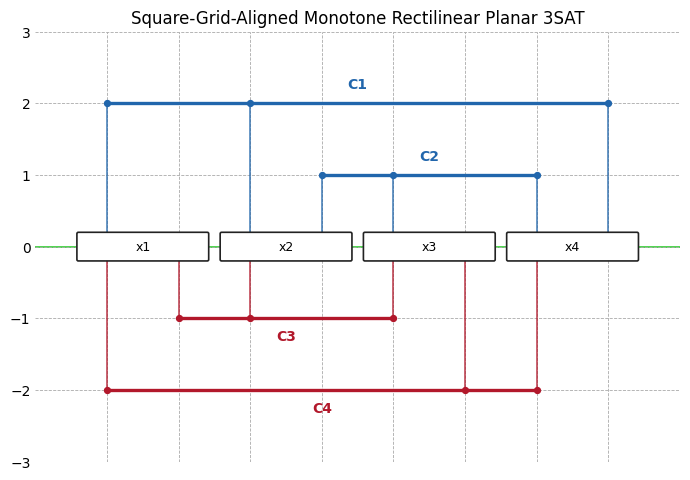

In [6]:
draw_instance(instance, positive_levels, negative_levels)

## Simple Transformations

In [7]:
import math

# MORE CONSTANTS
_SQRT3 = math.sqrt(3)
_GRID_STEP = _SQRT3 / 2


In [8]:
def compute_layout_alternating(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
) -> tuple[dict[int, int], dict[int, int], dict[tuple[str, int], int], dict[tuple[str, int], int]]:
    pos_queues = _build_queues(instance.positive, positive_levels)
    neg_queues = _build_queues(instance.negative, negative_levels)

    # Each variable gets paired (up, down) slots; width = 2 * max occupancy
    slot_count: dict[int, int] = {
        v: max(1, len(pos_queues.get(v, [])), len(neg_queues.get(v, [])))
        for v in range(1, instance.n + 1)
    }
    width: dict[int, int] = {v: 2 * slot_count[v] for v in range(1, instance.n + 1)}

    x_start: dict[int, int] = {}
    cursor = 0
    for v in range(1, instance.n + 1):
        x_start[v] = cursor
        cursor += width[v] + _GAP

    # Even columns go up (positive), odd columns go down (negative)
    pos_cx: dict[tuple[str, int], int] = {}
    for v, q in pos_queues.items():
        for i, clause in enumerate(q):
            pos_cx[(clause.label, v)] = x_start[v] + 2 * i

    neg_cx: dict[tuple[str, int], int] = {}
    for v, q in neg_queues.items():
        for i, clause in enumerate(q):
            neg_cx[(clause.label, v)] = x_start[v] + 2 * i + 1

    return x_start, width, pos_cx, neg_cx


def _fmt_sqrt3_half(k: int) -> str:
    """Format k * (√3/2) as a mathtext label."""
    if k == 0:
        return r"$0$"
    sign = "-" if k < 0 else ""
    a = abs(k)
    if a % 2 == 0:
        m = a // 2
        base = r"\sqrt{3}" if m == 1 else rf"{m}\sqrt{{3}}"
    else:
        base = r"\frac{\sqrt{3}}{2}" if a == 1 else rf"\frac{{{a}\sqrt{{3}}}}{{2}}"
    return rf"${sign}{base}$"


def draw_instance_alternating(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
):
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt = max(x_start_alt[v] + width_alt[v] for v in range(1, instance.n + 1))

    k_min = -(2 * max_negative + 1)
    k_max =   2 * max_positive  + 1
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP

    fig_width = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis = plt.subplots(figsize=(fig_width, fig_height))

    axis.axhline(0, color=_XAXIS_COLOUR, linewidth=1.2, zorder=1)

    for v in range(1, instance.n + 1):
        bx = x_start_alt[v] - 0.4
        bw = width_alt[v] - 1 + 0.8
        box = FancyBboxPatch(
            (bx, -_BOX_H / 2), bw, _BOX_H,
            boxstyle="round,pad=0.02",
            linewidth=1.2, edgecolor="#222222", facecolor="white", zorder=5,
        )
        axis.add_patch(box)
        axis.text(bx + bw / 2, 0, f"x{v}", ha="center", va="center", fontsize=9, zorder=6)

    _draw_side(axis, instance.positive, positive_levels, pos_cx_alt, direction=1,  color=_POS_COLOUR, y_scale=_SQRT3)
    _draw_side(axis, instance.negative, negative_levels, neg_cx_alt, direction=-1, color=_NEG_COLOUR, y_scale=_SQRT3)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(-1, total_x_alt)
    axis.set_ylim(y_bot, y_top)

    # x: integer gridlines, no labels
    axis.set_xticks(range(total_x_alt + 1))
    axis.tick_params(axis="x", bottom=False, labelbottom=False)

    # left y-axis: every √3/2
    ytick_positions = [k * _GRID_STEP for k in range(k_min, k_max + 1)]
    ytick_labels    = [_fmt_sqrt3_half(k) for k in range(k_min, k_max + 1)]
    axis.set_yticks(ytick_positions)
    axis.set_yticklabels(ytick_labels, fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.grid(True, color="#aaaaaa", linewidth=0.6, linestyle="--", zorder=0)

    axis.set_title(r"Alternating Square-Grid-Aligned Monotone Rectilinear Planar 3SAT (Vertically Scaled by $\sqrt{3}$)")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis

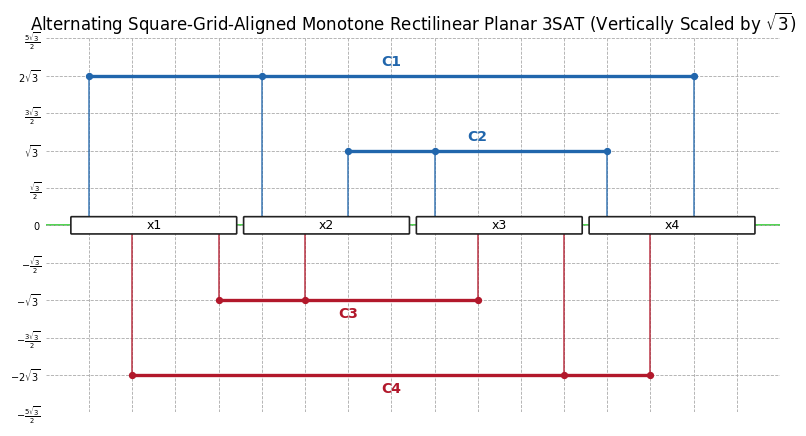

In [9]:
fig_alt, axis_alt = draw_instance_alternating(instance, positive_levels, negative_levels)
plt.show()

## Triangle Grid

In [10]:
# more constants
_ZIG = 0.5  # x-offset at odd half-step rows (defines the triangular grid)

In [11]:
def _zigzag_path(x: int, level: int, direction: int) -> tuple[list[float], list[float]]:
    """
    Path from (x, 0) to (x, direction * level * √3) along the triangular grid.
    Each level = 2 half-steps; odd half-steps shift x right by _ZIG.
    """
    n_steps = 2 * level
    xs = [x + (_ZIG if k % 2 == 1 else 0.0) for k in range(n_steps + 1)]
    ys = [direction * k * _GRID_STEP for k in range(n_steps + 1)]
    return xs, ys


def _draw_triangle_grid(
    axis,
    x_min: float,
    x_max: float,
    k_min: int,
    k_max: int,
    color: str = "#aaaaaa",
    linewidth: float = 0.6,
    linestyle: str = "--",
) -> None:
    """
    Three families of lines forming the triangular grid:
      Family 1 — horizontal:  y = k * _GRID_STEP
      Family 2 — slope +√3:   x = a + k/2   (integer a)
      Family 3 — slope −√3:   x = b − k/2   (integer b)
    All arithmetic is integer or integer/2, so no FP accumulation.
    """
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP
    kw = dict(color=color, linewidth=linewidth, linestyle=linestyle, zorder=0)

    for k in range(k_min, k_max + 1):
        axis.axhline(k * _GRID_STEP, **kw)

    # visible range: a + k/2 ∈ [x_min, x_max] for some k ∈ [k_min, k_max]
    a_min = math.floor(x_min - k_max / 2) - 1
    a_max = math.ceil( x_max - k_min / 2) + 1
    for a in range(a_min, a_max + 1):
        axis.plot([a + k_min / 2, a + k_max / 2], [y_bot, y_top], **kw)

    # visible range: b - k/2 ∈ [x_min, x_max] for some k ∈ [k_min, k_max]
    b_min = math.floor(x_min + k_min / 2) - 1
    b_max = math.ceil( x_max + k_max / 2) + 1
    for b in range(b_min, b_max + 1):
        axis.plot([b - k_min / 2, b - k_max / 2], [y_bot, y_top], **kw)


def _draw_side_triangle(
    axis,
    clauses: Iterable[Clause],
    levels: dict[str, int],
    connector_x: dict[tuple[str, int], int],
    direction: int,
    color: str,
) -> None:
    for clause in clauses:
        level = levels[clause.label]
        y = direction * level * _SQRT3
        xs = [connector_x[(clause.label, v)] for v in clause.variables]

        axis.plot([min(xs), max(xs)], [y, y], color=color, linewidth=2.4, zorder=3)
        for v in sorted(clause.variables):
            x = connector_x[(clause.label, v)]
            zx, zy = _zigzag_path(x, level, direction)
            axis.plot(zx, zy, color=color, linewidth=1.2, alpha=0.8, zorder=2)
            axis.scatter([x], [y], color=color, s=18, zorder=4)

        label_y = y + 0.16 * direction
        va = "bottom" if direction > 0 else "top"
        axis.text(
            (min(xs) + max(xs)) / 2, label_y, clause.label,
            ha="center", va=va, fontsize=10, color=color, fontweight="bold", zorder=4,
        )


def draw_instance_triangle(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
) -> tuple:
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt  = max(x_start_alt[v] + width_alt[v] for v in range(1, instance.n + 1))

    k_min  = -(2 * max_negative + 1)
    k_max  =   2 * max_positive  + 1
    y_bot  = k_min * _GRID_STEP
    y_top  = k_max * _GRID_STEP
    x_min, x_max = -1, total_x_alt

    fig_width  = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    axis.axhline(0, color=_XAXIS_COLOUR, linewidth=1.2, zorder=1)

    for v in range(1, instance.n + 1):
        bx = x_start_alt[v] - 0.4
        bw = width_alt[v] - 1 + 0.8
        axis.add_patch(FancyBboxPatch(
            (bx, -_BOX_H / 2), bw, _BOX_H,
            boxstyle="round,pad=0.02",
            linewidth=1.2, edgecolor="#222222", facecolor="white", zorder=5,
        ))
        axis.text(bx + bw / 2, 0, f"x{v}", ha="center", va="center", fontsize=9, zorder=6)

    _draw_side_triangle(axis, instance.positive, positive_levels, pos_cx_alt, direction=1,  color=_POS_COLOUR)
    _draw_side_triangle(axis, instance.negative, negative_levels, neg_cx_alt, direction=-1, color=_NEG_COLOUR)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top)

    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max)

    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])

    axis.set_title(r"Triangular-Grid-Aligned Monotone Rectilinear Planar 3SAT")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis

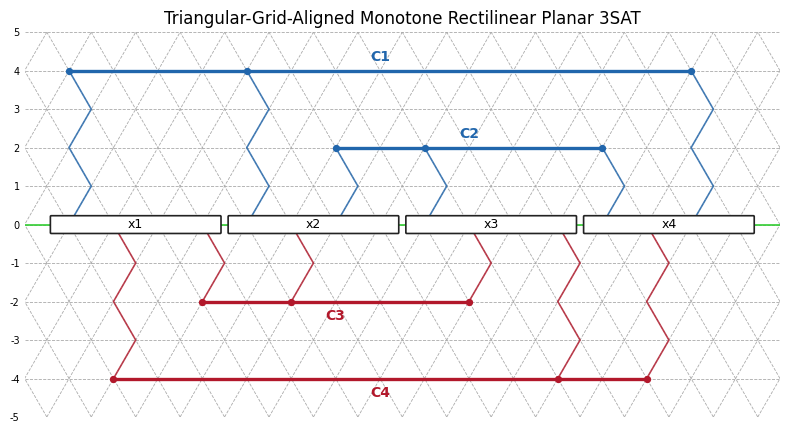

In [12]:
fig_tri, axis_tri = draw_instance_triangle(instance, positive_levels, negative_levels)
plt.show()

## Vertex Cover Conversion

In [13]:
_NODE_R_VAR    = 55    # scatter s= for variable-gadget nodes
_NODE_R_CLAUSE = 40    # scatter s= for clause-gadget (triangle) nodes

In [14]:
# ALL DRAWING FUNCTIONS MUST RETURN A NODE COUNT OF DRAWN COMPONENTS!!!

def _draw_variable_gadgets_vc(
    axis,
    instance: Instance,
    x_start: dict[int, int],
    width: dict[int, int],
) -> int:
    nc = 0
    for v in range(1, instance.n + 1):
        x0 = x_start[v]
        w  = width[v]
        # one edge per adjacent pair
        for i in range(w - 1):
            axis.plot([x0 + i, x0 + i + 1], [0, 0],
                      color="#444444", linewidth=1.2, zorder=2)
        # nodes: even offset from x0 = true (filled), odd = false (hollow)
        for i in range(w):
            x = x0 + i
            if i % 2 == 0:
                axis.scatter([x], [0], s=_NODE_R_VAR, color="#222222",
                             linewidths=1.2, zorder=6)
            else:
                axis.scatter([x], [0], s=_NODE_R_VAR, facecolors="white",
                             edgecolors="#222222", linewidths=1.2, zorder=6)
            nc = nc + 1
        # variable label below the chain
        axis.text(x0 + (w - 1) / 2, -0.28, f"x{v}",
                  ha="center", va="top", fontsize=8, color="#333333")
    # count number of pts we plotted
    return nc


def _draw_or_gadget(
    axis,
    x_M: int,
    y: float,
    direction: int,
    color: str,
    x_L: int,
    x_R: int,
) -> int:
    A  = (float(x_M), y)
    B  = (x_M - 0.5,  y + direction * _GRID_STEP)
    C  = (x_M + 0.5,  y + direction * _GRID_STEP)
    jl = x_M - 1
    jr = x_M + 1

    kw = dict(color=color, linewidth=1.5, zorder=2)

    # clause bar: left and right segments around the gadget
    axis.plot([x_L, jl], [y, y], **kw)
    axis.plot([jr,  x_R], [y, y], **kw)

    # junction → triangle apex nodes (unit-length grid edges)
    axis.plot([jl, B[0]], [y, B[1]], **kw)
    axis.plot([jr, C[0]], [y, C[1]], **kw)

    # triangle edges A-B, A-C, B-C (all unit-length)
    axis.plot([A[0], B[0]], [A[1], B[1]], **kw)
    axis.plot([A[0], C[0]], [A[1], C[1]], **kw)
    axis.plot([B[0], C[0]], [B[1], C[1]], **kw)

    # triangle nodes
    for pt in (A, B, C):
        if (pt[1] < 0):
            axis.scatter([pt[0]], [pt[1]], s=_NODE_R_CLAUSE, color=color, linewidths=1.2, zorder=5)
        elif (pt[1] > 0):
            axis.scatter([pt[0]], [pt[1]], s=_NODE_R_CLAUSE, facecolors="white", edgecolors=color, linewidths=1.2, zorder=5)
    # triange has 3 nodes
    return 3


def _draw_side_vc(
    axis,
    clauses: Iterable[Clause],
    levels: dict[str, int],
    connector_x: dict[tuple[str, int], int],
    direction: int,
    color: str,
) -> int:
    nc = 0
    for clause in clauses:
        level    = levels[clause.label]
        y        = direction * level * _SQRT3
        L, M, R  = sorted(clause.variables)
        x_L = connector_x[(clause.label, L)]
        x_M = connector_x[(clause.label, M)]
        x_R = connector_x[(clause.label, R)]

        # zigzag connectors from variable gadget to clause bar
        # (intermediate subdivision nodes omitted for now — improve iteratively)
        for v in sorted(clause.variables):
            x = connector_x[(clause.label, v)]
            zx, zy = _zigzag_path(x, level, direction)
            axis.plot(zx, zy, color=color, linewidth=1.2, alpha=0.8, zorder=2)

        nc = nc + _draw_or_gadget(axis, x_M, y, direction, color, x_L, x_R)

        # label just beyond the triangle apex row
        apex_y  = y + direction * _GRID_STEP
        label_y = apex_y + direction * 0.16
        va = "bottom" if direction > 0 else "top"
        axis.text(x_M, label_y, clause.label, ha="center", va=va, fontsize=10, color=color, fontweight="bold", zorder=4)

    # return sum of nodes (or len(clauses) * 3)
    return nc


def draw_instance_vertex_cover(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
) -> tuple:
    nc = 0
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt  = max(x_start_alt[v] + width_alt[v] for v in range(1, instance.n + 1))

    # +1 for clause bar row, +1 for triangle apex row (beyond draw_instance_triangle's range)
    k_min = -(2 * max_negative + 2)
    k_max =   2 * max_positive  + 2
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP
    x_min, x_max = -1, total_x_alt

    fig_width  = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    nc = nc + _draw_variable_gadgets_vc(axis, instance, x_start_alt, width_alt)
    nc = nc + _draw_side_vc(axis, instance.positive, positive_levels, pos_cx_alt, direction=1,  color=_POS_COLOUR)
    nc = nc + _draw_side_vc(axis, instance.negative, negative_levels, neg_cx_alt, direction=-1, color=_NEG_COLOUR)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top)

    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max)

    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])

    axis.set_title(r"Triangle-Grid-Aligned Planar Vertex Cover with Max Degree 3")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis, nc

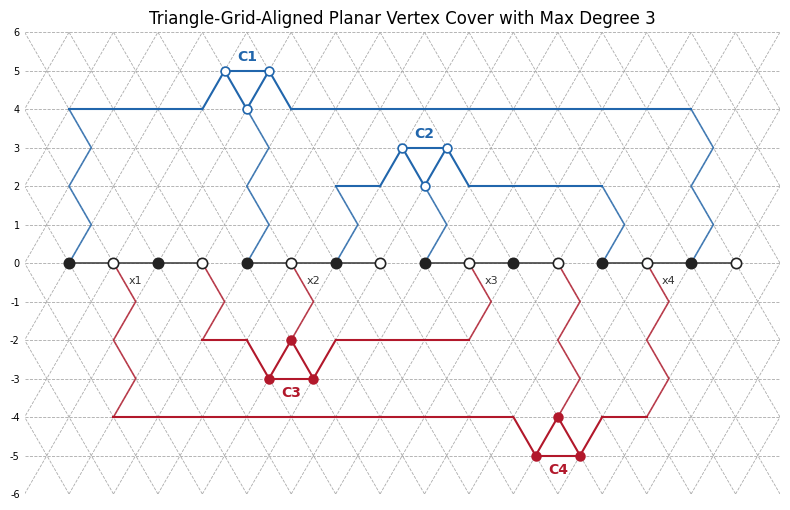

In [15]:
fig_vc, axis_vc, node_count = draw_instance_vertex_cover(instance, positive_levels, negative_levels)
plt.show()

In [16]:
# value of k that makes the problem instance NP-complete
# 2 * m + (number of non-clause nodes / 2)
print("[DEBUG] node count is", node_count)
non_clause_nodes = node_count - 3 * instance.m
print("k = 2m + non_clause_nodes/2 =", 2 * instance.m + int(non_clause_nodes/2))
# ideally render this in LaTeX

[DEBUG] node count is 28
k = 2m + non_clause_nodes/2 = 16


## Triangle-Grid-Embedding

In [17]:
_NODE_R_CONNECT = 22

In [18]:
# ALL DRAWING FUNCTIONS MUST RETURN A NODE COUNT OF DRAWN COMPONENTS!!!

# this is literally the same logic as _draw_or_gadget
# **except** pt[1] > 0 and pt[1] < 0 are swapped in the if-elif
def _draw_or_gadget_embedding(
    axis,
    x_M: int,
    y: float,
    direction: int,
    color: str,
    x_L: int,
    x_R: int,
) -> int:
    A  = (float(x_M), y)
    B  = (x_M - 0.5,  y + direction * _GRID_STEP)
    C  = (x_M + 0.5,  y + direction * _GRID_STEP)
    jl = x_M - 1
    jr = x_M + 1

    kw = dict(color=color, linewidth=1.5, zorder=2)

    # clause bar: left and right segments around the gadget
    axis.plot([x_L, jl], [y, y], **kw)
    axis.plot([jr,  x_R], [y, y], **kw)

    # junction → triangle apex nodes (unit-length grid edges)
    axis.plot([jl, B[0]], [y, B[1]], **kw)
    axis.plot([jr, C[0]], [y, C[1]], **kw)

    # triangle edges A-B, A-C, B-C (all unit-length)
    axis.plot([A[0], B[0]], [A[1], B[1]], **kw)
    axis.plot([A[0], C[0]], [A[1], C[1]], **kw)
    axis.plot([B[0], C[0]], [B[1], C[1]], **kw)

    # triangle nodes
    for pt in (A, B, C):
        if (pt[1] > 0):
            axis.scatter([pt[0]], [pt[1]], s=_NODE_R_CLAUSE, color=color, linewidths=1.2, zorder=5)
        elif (pt[1] < 0):
            axis.scatter([pt[0]], [pt[1]], s=_NODE_R_CLAUSE, facecolors="white", edgecolors=color, linewidths=1.2, zorder=5)
    # triangle = 3 pts
    return 3



def _draw_bipartite_vertex(
    axis,
    x: float,
    y: float,
    parity: int,
    size: float = _NODE_R_CONNECT,
) -> int:
    """
    Draw a connector-gadget vertex using the global checkerboard
    2-colouring of the triangular lattice.

    parity = 0 -> filled
    parity = 1 -> hollow
    """
    draw_colour = _POS_COLOUR
    if (y < 0):
        draw_colour = _NEG_COLOUR

    if parity % 2 == 0:
        axis.scatter(
            [x], [y],
            s=size,
            color=draw_colour,
            linewidths=1.0,
            zorder=5,
        )
    else:
        axis.scatter(
            [x], [y],
            s=size,
            facecolors="white",
            edgecolors=draw_colour,
            linewidths=1.0,
            zorder=5,
        )
    # we drew 1 point
    return 1


def _triangle_grid_parity(x: float, y: float) -> int:
    """
    Bipartition of the triangular lattice.

    Parity can be determined based on x-coord:
    - even integer       -> filled
    - even integer + 0.5 -> hollow
    - odd integer        -> hollow
    - odd integer + 0.5  -> filled

    idk why this works, but the pattern works from observation...
    (and yes this is my algorithm lol)
    """

    FILLED = 0
    HOLLOW = 1

    # to avoid Floating point mess, use ints:
    # ceil of int = floor of same int
    # ceil of (int + 0.5) > floor of same (int + 0.5)
    floor = int(x)
    ceil = int(math.ceil(x))
    if (floor % 2 == 0):
        if (floor < ceil):
            return HOLLOW
        return FILLED
    else:
        if (floor < ceil):
            return FILLED
        return HOLLOW


def _draw_unit_path_vertices(
    axis,
    xs: list[float],
    ys: list[float],
) -> int:
    """
    Draw all interior vertices of a triangle-grid path.

    Endpoints are skipped because the caller typically draws
    those separately.
    """
    nc = 0

    for x, y in zip(xs[1:-1], ys[1:-1]):
        nc = nc + _draw_bipartite_vertex(
            axis,
            x,
            y,
            _triangle_grid_parity(x, y),
        )
    # could also calculate nc using len() and multiplication...
    return nc

In [19]:
def _draw_side_vc_embedding(
    axis,
    clauses: Iterable[Clause],
    levels: dict[str, int],
    connector_x: dict[tuple[str, int], int],
    direction: int,
    color: str,
) -> int:

    nc = 0

    for clause in clauses:
        level = levels[clause.label]
        y     = direction * level * _SQRT3

        L, M, R = sorted(clause.variables)

        x_L = connector_x[(clause.label, L)]
        x_M = connector_x[(clause.label, M)]
        x_R = connector_x[(clause.label, R)]

        #
        # connector wires
        #
        for v in sorted(clause.variables):
            x = connector_x[(clause.label, v)]

            zx, zy = _zigzag_path(x, level, direction)

            axis.plot(
                zx,
                zy,
                color=color,
                linewidth=1.2,
                alpha=0.8,
                zorder=2,
            )

            nc = nc + _draw_unit_path_vertices(axis, zx, zy)

        #
        # clause-bar subdivision vertices
        #
        for x in range(x_L, x_M):
            nc = nc + _draw_bipartite_vertex(
                axis,
                x,
                y,
                _triangle_grid_parity(x, y),
            )

        for x in range(x_M + 1, x_R + 1):
            nc = nc + _draw_bipartite_vertex(
                axis,
                x,
                y,
                _triangle_grid_parity(x, y),
            )

        nc = nc + _draw_or_gadget_embedding(
            axis,
            x_M,
            y,
            direction,
            color,
            x_L,
            x_R,
        )

        apex_y  = y + direction * _GRID_STEP
        label_y = apex_y + direction * 0.16

        va = "bottom" if direction > 0 else "top"

        axis.text(
            x_M,
            label_y,
            clause.label,
            ha="center",
            va=va,
            fontsize=10,
            color=color,
            fontweight="bold",
            zorder=4,
        )

    # nc should be comprehensive?
    return nc

In [20]:
def draw_instance_vertex_cover_embedding(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
) -> tuple:

    nc = 0
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt  = max(x_start_alt[v] + width_alt[v] for v in range(1, instance.n + 1))

    # +1 for clause bar row, +1 for triangle apex row (beyond draw_instance_triangle's range)
    k_min = -(2 * max_negative + 2)
    k_max =   2 * max_positive  + 2
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP
    x_min, x_max = -1, total_x_alt

    fig_width  = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis  = plt.subplots(figsize=(fig_width, fig_height))

    nc = nc + _draw_variable_gadgets_vc(axis, instance, x_start_alt, width_alt)
    nc = nc + _draw_side_vc_embedding(axis, instance.positive, positive_levels, pos_cx_alt, direction=1,  color=_POS_COLOUR)
    nc = nc + _draw_side_vc_embedding(axis, instance.negative, negative_levels, neg_cx_alt, direction=-1, color=_NEG_COLOUR)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(x_min, x_max)
    axis.set_ylim(y_bot, y_top)

    _draw_triangle_grid(axis, x_min, x_max, k_min, k_max)

    axis.set_yticks([k * _GRID_STEP for k in range(k_min, k_max + 1)])
    axis.set_yticklabels([str(k) for k in range(k_min, k_max + 1)], fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.set_xticks([])

    axis.set_title(r"Triangle-Grid-Embedded Planar Vertex Cover with Max Degree 3")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis, nc

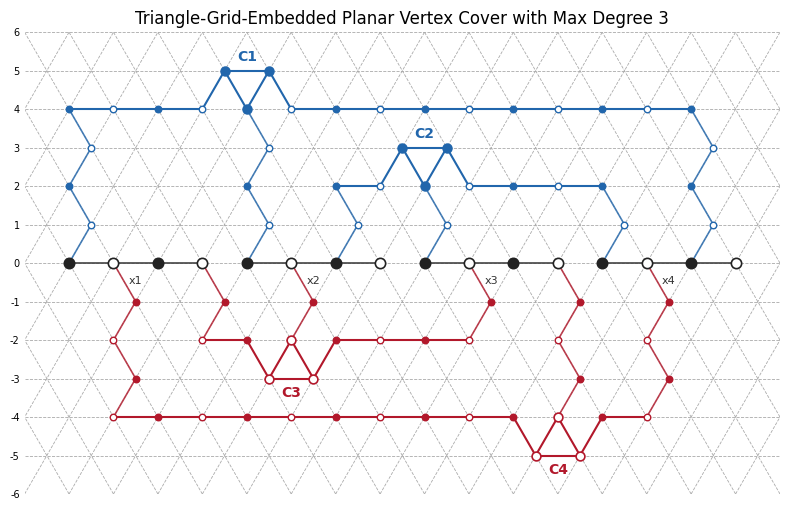

In [21]:
willthiswork, idkman, node_count_emb = draw_instance_vertex_cover_embedding(instance, positive_levels, negative_levels)
plt.show()

In [22]:
# value of k that makes the problem instance NP-complete
# 2 * m + (number of non-clause nodes / 2)
print("[DEBUG] node count is", node_count_emb) # nc should be 90 for input.yaml
non_clause_nodes_emb = node_count_emb - 3 * instance.m
print("k = 2m + nodes/2 =", 2 * instance.m + int(non_clause_nodes_emb/2))
# ideally render this in LaTeX

[DEBUG] node count is 90
k = 2m + nodes/2 = 47
